In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     LSTM, Dense, Reshape,
                                     Multiply, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     LSTM, Dense, Reshape,
                                     Multiply, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns


SAVE_PATH  = "/content/drive/MyDrive/final_project/"
CREMA_PATH = "/content/drive/MyDrive/project/AudioWAV/"

print("Imports done ✅")
print(f"CREMA path : {CREMA_PATH}")
print(f"Save path  : {SAVE_PATH}")
print("Imports done ✅")
print(f"CREMA path : {CREMA_PATH}")
print(f"Save path  : {SAVE_PATH}")

Imports done ✅
CREMA path : /content/drive/MyDrive/project/AudioWAV/
Save path  : /content/drive/MyDrive/final_project/
Imports done ✅
CREMA path : /content/drive/MyDrive/project/AudioWAV/
Save path  : /content/drive/MyDrive/final_project/


In [ ]:
SAVE_PATH  = "/content/drive/MyDrive/final_project/"
CREMA_PATH = "/content/drive/MyDrive/project/crema/AudioWAV"

emotion_map = {
    'ANG': 'Negative',
    'DIS': 'Negative',
    'FEA': 'Negative',
    'SAD': 'Negative',
    'HAP': 'Positive',
    'NEU': 'Positive',
}

file_paths = []
labels     = []

for file in sorted(os.listdir(CREMA_PATH)):
    if file.endswith(".wav"):
        parts = file.split("_")
        if len(parts) >= 3:
            emotion_code = parts[2].upper()
            if emotion_code in emotion_map:
                file_paths.append(
                    os.path.join(CREMA_PATH, file)
                )
                labels.append(
                    emotion_map[emotion_code]
                )

file_paths = np.array(file_paths)
labels     = np.array(labels)

print(f"Total files before balance: {len(file_paths)}")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} ({c/len(labels)*100:.1f}%)")

# Undersample Negative to match Positive
pos_paths  = file_paths[labels == 'Positive']
neg_paths  = file_paths[labels == 'Negative']
pos_labels = labels[labels == 'Positive']
neg_labels = labels[labels == 'Negative']

np.random.seed(42)
neg_idx = np.random.choice(
    len(neg_paths),
    len(pos_paths),
    replace=False
)

file_paths = np.concatenate([
    pos_paths,
    neg_paths[neg_idx]
])
labels = np.concatenate([
    pos_labels,
    neg_labels[neg_idx]
])

shuffle_idx = np.random.permutation(len(file_paths))
file_paths  = file_paths[shuffle_idx]
labels      = labels[shuffle_idx]

print(f"\nAfter undersampling:")
print(f"Total files : {len(file_paths)}")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} ({c/len(labels)*100:.1f}%)")

Total files before balance: 7535
  Negative: 5148 (68.3%)
  Positive: 2387 (31.7%)

After undersampling:
Total files : 4774
  Negative: 2387 (50.0%)
  Positive: 2387 (50.0%)


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(f"Classes : {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    file_paths, labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)

print(f"\nTrain : {len(X_train)} "
      f"({len(X_train)/len(file_paths)*100:.0f}%)")
print(f"Val   : {len(X_val)}   "
      f"({len(X_val)/len(file_paths)*100:.0f}%)")
print(f"Test  : {len(X_test)}  "
      f"({len(X_test)/len(file_paths)*100:.0f}%)")
print("Zero leakage ✅")

np.save(SAVE_PATH + "voice_labels.npy", le.classes_)
print("Labels saved ✅")

Classes : ['Negative' 'Positive']

Train : 3341 (70%)
Val   : 478   (10%)
Test  : 955  (20%)
Zero leakage ✅
Labels saved ✅


In [ ]:
SAVE_PATH  = "/content/drive/MyDrive/final_project/"
CREMA_PATH = "/content/drive/MyDrive/project/AudioWAV/"

def extract_features(file_path, augment=False):
    try:
        audio, sr = librosa.load(
            file_path, duration=3.0, offset=0.5
        )

        if augment:
            choice = np.random.randint(0, 3)
            if choice == 0:
                audio = audio + np.random.normal(
                    0, 0.005, audio.shape
                )
            elif choice == 1:
                rate  = np.random.uniform(0.85, 1.15)
                audio = librosa.effects.time_stretch(
                    audio, rate=rate
                )
            elif choice == 2:
                steps = np.random.randint(-2, 2)
                audio = librosa.effects.pitch_shift(
                    audio, sr=sr, n_steps=steps
                )

        target = sr * 3
        if len(audio) < target:
            audio = np.pad(
                audio, (0, target - len(audio))
            )
        else:
            audio = audio[:target]

        mel    = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=128, fmax=8000
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mfcc   = librosa.feature.mfcc(
            y=audio, sr=sr, n_mfcc=40
        )
        chroma = librosa.feature.chroma_stft(
            y=audio, sr=sr, n_chroma=12
        )

        def norm(x):
            return (x - x.mean()) / (x.std() + 1e-6)

        combined = np.vstack([
            norm(mel_db),
            norm(mfcc),
            norm(chroma)
        ])

        return combined

    except Exception as e:
        print(f"Error: {file_path} → {e}")
        return None

sample = extract_features(file_paths[0])
print(f"Feature shape : {sample.shape}")
print(f"Expected      : (180, ~130)")

Feature shape : (180, 130)
Expected      : (180, ~130)


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

def build_set(paths, augment=False, label=""):
    X, failed = [], 0
    for i, fp in enumerate(paths):
        f = extract_features(fp, augment=augment)
        if f is not None:
            X.append(f)
        else:
            failed += 1
        if i % 500 == 0:
            print(f"  {label}: {i}/{len(paths)}")
    print(f"  {label} done — failed: {failed}")
    return np.array(X)

print("Extracting train...")
X_train_feat = build_set(
    X_train, augment=True, label="Train"
)

print("\nExtracting val...")
X_val_feat   = build_set(
    X_val, augment=False, label="Val"
)

print("\nExtracting test...")
X_test_feat  = build_set(
    X_test, augment=False, label="Test"
)

X_train_feat = X_train_feat[..., np.newaxis]
X_val_feat   = X_val_feat[...,   np.newaxis]
X_test_feat  = X_test_feat[...,  np.newaxis]

print(f"\nX_train : {X_train_feat.shape}")
print(f"X_val   : {X_val_feat.shape}")
print(f"X_test  : {X_test_feat.shape}")
print("Zero leakage confirmed ✅")

Extracting train...
  Train: 0/3341
  Train: 500/3341
  Train: 1000/3341
  Train: 1500/3341
  Train: 2000/3341
  Train: 2500/3341
  Train: 3000/3341
  Train done — failed: 0

Extracting val...
  Val: 0/478
  Val done — failed: 0

Extracting test...
  Test: 0/955
  Test: 500/955
  Test done — failed: 0

X_train : (3341, 180, 130, 1)
X_val   : (478, 180, 130, 1)
X_test  : (955, 180, 130, 1)
Zero leakage confirmed ✅


In [ ]:
def attention_block(inputs):
    attention = Dense(
        inputs.shape[-1], activation='softmax'
    )(inputs)
    return Multiply()([inputs, attention])

def build_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Conv2D(64,  (3,3),
                activation='relu',
                padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.2)(x)

    x = Conv2D(128, (3,3),
                activation='relu',
                padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.2)(x)

    x = Conv2D(256, (3,3),
                activation='relu',
                padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)

    x = LSTM(128, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)

    x = attention_block(x)

    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

model = build_model(
    input_shape=(
        X_train_feat.shape[1],
        X_train_feat.shape[2],
        1
    )
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 130,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 180, 130,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 180, 130,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 90, 65,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 90, 65,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 90, 65,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 65,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 45, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 45, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 45, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 22, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 22, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 22, 4096)  │          0 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 22, 128)   │  2,163,200 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 128)   │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 22, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 22, 64)    │     49,408 │ dropout_3[0][0] 

 Total params: 2,679,233 (10.22 MB)

 Trainable params: 2,677,953 (10.22 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)
print("Model compiled ✅")

Model compiled ✅


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=12,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train_feat, y_train,
    epochs=80,
    batch_size=16,
    validation_data=(X_val_feat, y_val),
    callbacks=callbacks,
    verbose=1
)

print("Training complete ✅")

Epoch 1/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.5908 - auc: 0.6196 - loss: 0.6693 - val_accuracy: 0.6276 - val_auc: 0.6714 - val_loss: 0.6729 - learning_rate: 5.0000e-04
Epoch 2/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.6034 - auc: 0.6349 - loss: 0.6629 - val_accuracy: 0.6339 - val_auc: 0.6640 - val_loss: 0.6462 - learning_rate: 5.0000e-04
Epoch 3/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.6124 - auc: 0.6543 - loss: 0.6551 - val_accuracy: 0.6590 - val_auc: 0.7124 - val_loss: 0.6372 - learning_rate: 5.0000e-04
Epoch 4/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.6315 - auc: 0.6763 - loss: 0.6403 - val_accuracy: 0.6444 - val_auc: 0.6962 - val_loss: 0.6402 - learning_rate: 5.0000e-04
Epoch 5/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.6462 - auc: 0.6905 - loss: 0.6329 - val_accuracy: 0.5795 - val_auc: 0.6555 - val_loss: 0.7200 - learning_rate: 5.0000e-04
Epoch 6/80
209/209 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/s


Test Accuracy : 69.74%
Test AUC      : 0.7543
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.60      0.67       478
    Positive       0.67      0.79      0.72       477

    accuracy                           0.70       955
   macro avg       0.70      0.70      0.69       955
weighted avg       0.70      0.70      0.69       955



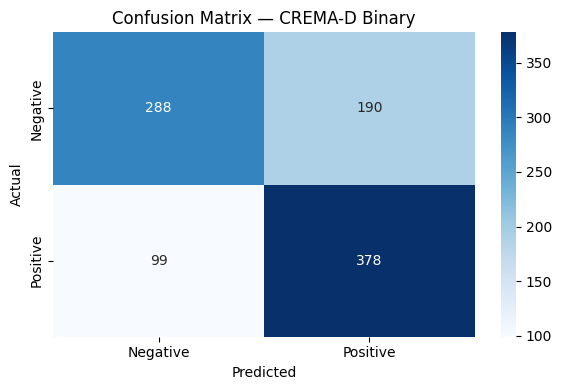

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

# Evaluate
results = model.evaluate(
    X_test_feat, y_test, verbose=0
)
print(f"\nTest Accuracy : {results[1]*100:.2f}%")
print(f"Test AUC      : {results[2]:.4f}")

# Predictions
y_pred = (
    model.predict(X_test_feat).flatten() >= 0.5
).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix — CREMA-D Binary')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

model.save(
    SAVE_PATH + "voice_sentiment_model.h5"
)
np.save(
    SAVE_PATH + "voice_labels.npy",
    le.classes_
)

print("Saved ✅")
print("  voice_sentiment_model.h5")
print("  voice_labels.npy")

Saved ✅
  voice_sentiment_model.h5
  voice_labels.npy
